In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold, StratifiedKFold
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
import math
from xgboost import XGBRegressor

In [2]:
# Reading HSP and SMILES data 
gpHSP_data = pd.read_csv('/Users/favour/Desktop/untitled folder/dataset/hansen_1k_smiles_shorter.csv')

mol_smiles = gpHSP_data['SMILES']
hansen_d = gpHSP_data['hansen_d']
hansen_p = gpHSP_data['hansen_p']
hansen_h = gpHSP_data['hansen_h']
mol_number = gpHSP_data['number']
mol_name = gpHSP_data['Molecule']

# calculate total sobubility from HSP
hansen_total = np.sqrt((hansen_d*hansen_d + hansen_p*hansen_p + hansen_h*hansen_h))

In [3]:
# generate fingeprints: Morgan fingerprint with radius 8 with nBits 2048
fps = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(x), 8, nBits=2048) for x in gpHSP_data['SMILES']]
#convert fps into numpy array
np_fps = np.asarray(fps)
np_fps.shape

# generate MACCS fingerprints
#maccs_fps = [MACCSkeys.GenMACCSKeys (Chem.MolFromSmiles(x)) for x in gpHSP_data['smiles']]

[14:12:54] DEPRECATION WARNING: please use MorganGenerator
[14:12:54] DEPRECATION WARNING: please use MorganGenerator
[14:12:54] DEPRECATION WARNING: please use MorganGenerator
[14:12:54] DEPRECATION WARNING: please use MorganGenerator
[14:12:54] DEPRECATION WARNING: please use MorganGenerator
[14:12:54] DEPRECATION WARNING: please use MorganGenerator
[14:12:54] DEPRECATION WARNING: please use MorganGenerator
[14:12:54] DEPRECATION WARNING: please use MorganGenerator
[14:12:54] DEPRECATION WARNING: please use MorganGenerator
[14:12:54] DEPRECATION WARNING: please use MorganGenerator
[14:12:54] DEPRECATION WARNING: please use MorganGenerator
[14:12:54] DEPRECATION WARNING: please use MorganGenerator
[14:12:54] DEPRECATION WARNING: please use MorganGenerator
[14:12:54] DEPRECATION WARNING: please use MorganGenerator
[14:12:54] DEPRECATION WARNING: please use MorganGenerator
[14:12:54] DEPRECATION WARNING: please use MorganGenerator
[14:12:54] DEPRECATION WARNING: please use MorganGenerat

(1183, 2048)

Fold:1, Train set: 985, Test set:198
MAE  : 1.9876
RMSE : 3.2642
R2   : 0.5575


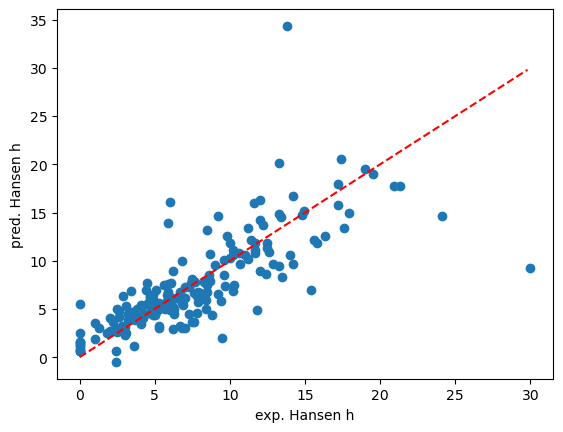

Fold:2, Train set: 986, Test set:197
MAE  : 2.2416
RMSE : 3.8210
R2   : 0.5450


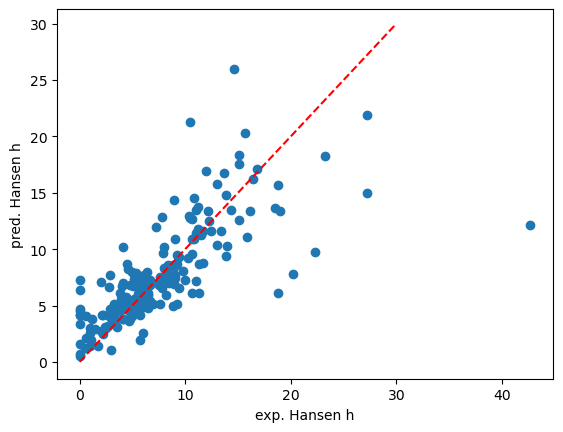

Fold:3, Train set: 986, Test set:197
MAE  : 2.1152
RMSE : 3.7964
R2   : 0.4946


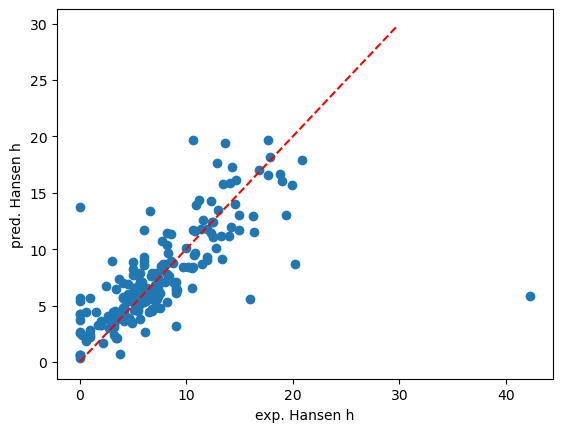

Fold:4, Train set: 986, Test set:197
MAE  : 2.0726
RMSE : 3.2599
R2   : 0.5871


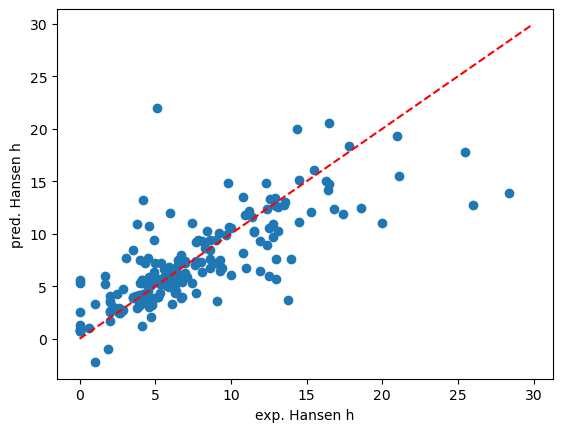

Fold:5, Train set: 986, Test set:197
MAE  : 2.0898
RMSE : 3.1599
R2   : 0.5477


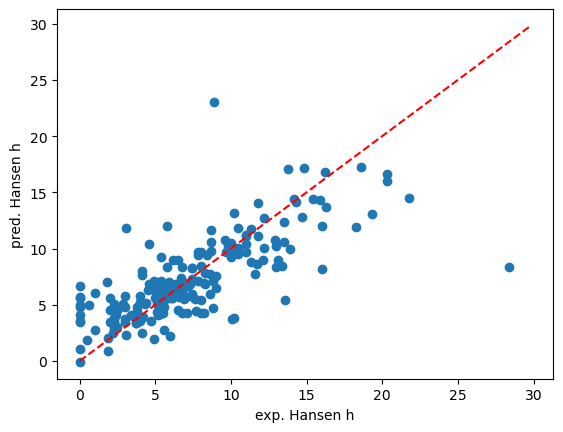

Fold:6, Train set: 986, Test set:197
MAE  : 2.1760
RMSE : 3.5177
R2   : 0.5536


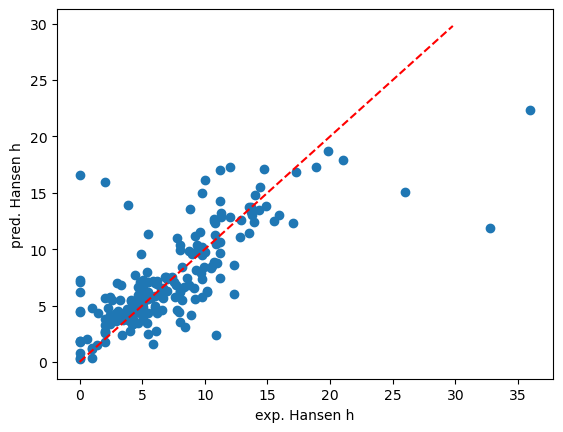


=== 6-Fold CV Summary (Hansen h) ===
MAE  : 2.1138 ± 0.0876
RMSE : 3.4698 ± 0.2880
R2   : 0.5476 ± 0.0300


In [4]:
import numpy as np
import pandas as pd
import math
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

kf = KFold(n_splits=6, shuffle=True, random_state=42)

# store metrics
mae_scores = []
rmse_scores = []
r2_scores = []

cnt = 1

for train_index, test_index in kf.split(np_fps, hansen_h):
    print(f'Fold:{cnt}, Train set: {len(train_index)}, Test set:{len(test_index)}')

    fps_train, fps_test = np_fps[train_index], np_fps[test_index]
    hansen_train, hansen_test = hansen_h[train_index], hansen_h[test_index]
    index_test = mol_number[test_index]
    smiles_test = mol_smiles[test_index]

    # train model
    model = XGBRegressor()
    model.fit(fps_train, hansen_train)
    hansen_pred = model.predict(fps_test)

    # calculate metrics
    fold_mae = mean_absolute_error(hansen_test, hansen_pred)
    fold_rmse = math.sqrt(mean_squared_error(hansen_test, hansen_pred))
    fold_r2 = r2_score(hansen_test, hansen_pred)

    # store metrics
    mae_scores.append(fold_mae)
    rmse_scores.append(fold_rmse)
    r2_scores.append(fold_r2)

    # print fold results
    print(f"MAE  : {fold_mae:.4f}")
    print(f"RMSE : {fold_rmse:.4f}")
    print(f"R2   : {fold_r2:.4f}")

    # save predictions
    out_df = pd.DataFrame({
        "Mol_No": index_test,
        "SMILES": smiles_test,
        "actual": hansen_test,
        "predict": hansen_pred
    })

    out_df.to_csv(f'fps_xgboost_hansen_h_fold_{cnt}.csv', index=False)

    # plot
    ln = np.arange(0, 30, 0.2)
    plt.plot(ln, ln, 'r--')
    plt.scatter(hansen_test, hansen_pred)
    plt.xlabel('exp. Hansen h')
    plt.ylabel('pred. Hansen h')
    plt.show()

    cnt += 1

# Convert to arrays
mae_scores = np.array(mae_scores)
rmse_scores = np.array(rmse_scores)
r2_scores = np.array(r2_scores)

# Print CV summary
print("\n=== 6-Fold CV Summary (Hansen h) ===")
print(f"MAE  : {mae_scores.mean():.4f} ± {mae_scores.std(ddof=1):.4f}")
print(f"RMSE : {rmse_scores.mean():.4f} ± {rmse_scores.std(ddof=1):.4f}")
print(f"R2   : {r2_scores.mean():.4f} ± {r2_scores.std(ddof=1):.4f}")

In [5]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools
from rdkit.Chem.Draw import IPythonConsole
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
import math

In [6]:
# load predicted values from the previous 6-fold cross-validation as df
fps_xgboost_h_1 = pd.read_csv('fps_xgboost_hansen_h_fold_1.csv')
fps_xgboost_h_2 = pd.read_csv('fps_xgboost_hansen_h_fold_2.csv')
fps_xgboost_h_3 = pd.read_csv('fps_xgboost_hansen_h_fold_3.csv')
fps_xgboost_h_4 = pd.read_csv('fps_xgboost_hansen_h_fold_4.csv')
fps_xgboost_h_5 = pd.read_csv('fps_xgboost_hansen_h_fold_5.csv')
fps_xgboost_h_6 = pd.read_csv('fps_xgboost_hansen_h_fold_6.csv')
# concat the data, rename columns (actual=experimentally determined value)
fps_xgboost = pd.concat((fps_xgboost_h_1, fps_xgboost_h_2, fps_xgboost_h_3, fps_xgboost_h_4, fps_xgboost_h_5, fps_xgboost_h_6),axis=0)
fps_xgboost = fps_xgboost.rename({'3': 'SMILES', '4':'Mol_No', '5': 'actual', '6':'predict'}, axis='columns')

In [7]:
# MAE, AE and RMSE give an idea of the error distribution
print(mean_absolute_error(fps_xgboost['actual'], fps_xgboost['predict']))

#RMSEs
print(math.sqrt(mean_squared_error(fps_xgboost['actual'], fps_xgboost['predict'])))

# R^2 Coefficient of Determination
print(r2_score(fps_xgboost['actual'], fps_xgboost['predict']))

2.1136864289264583
3.4796031635693843
0.5466934047217786


In [8]:
len(fps_xgboost)

1183

In [9]:
# calculate the residual value for each molecule
fps_xgboost['residual']= fps_xgboost['predict']-fps_xgboost['actual']

In [10]:
# calculate standardised deviation of the residuals (sdr) of the dataset
# equations used: sdr = sqrt((sum((residual)**2))/(n-2))
sdr = np.sqrt((fps_xgboost['residual']**2).sum()/(len(fps_xgboost)-2))
sdr

np.float64(3.482548236600675)

In [11]:
# calculate how many sdr each molecule's predicted value is away from the exp value 
fps_xgboost['std_residual'] = fps_xgboost['residual']/sdr
fps_xgboost['std_residual']

0     -0.172040
1     -0.700847
2      0.340134
3      0.733250
4      0.565290
         ...   
192   -1.047414
193   -0.324496
194   -0.565261
195    0.278856
196    0.548659
Name: std_residual, Length: 1183, dtype: float64

In [12]:
# n is 2 or 3. Points 2 or 3 sdr away from the prediction line are likely to be outliers
n = 3
fps_xgboost_outliers = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]
fps_xgboost_outliers

,Mol_No,SMILES,actual,predict,residual,std_residual
144,847,COO,30.0,9.295645,-20.704355,-5.945174
180,1081,CC(C)(c1ccc(O)cc1)c2c(Br)cc(OBr)c(Br)c2Br,13.8,34.345990,20.545990,5.899700
15,72,Oc1ccc(O)cc1,27.2,14.977636,-12.222364,-3.509604
29,141,OCC(Cl)CCl,14.6,25.963308,11.363308,3.262929
39,239,Cc1ccc(O)c(c1)C(C)(C)C,10.5,21.306911,10.806911,3.103162
53,319,CC=NO,20.2,7.800064,-12.399936,-3.560593
64,367,N,18.8,6.080288,-12.719712,-3.652415
132,764,OO,42.7,12.125521,-30.574479,-8.779341
139,820,CO,22.3,9.792129,-12.507871,-3.591586
85,475,BrC#N,0.0,13.768794,13.768794,3.953655


In [13]:
# Set the default text font size
plt.rc('font', size=22)

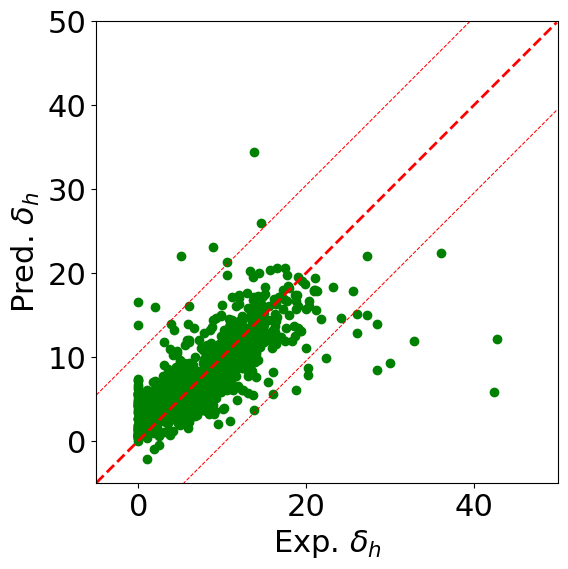

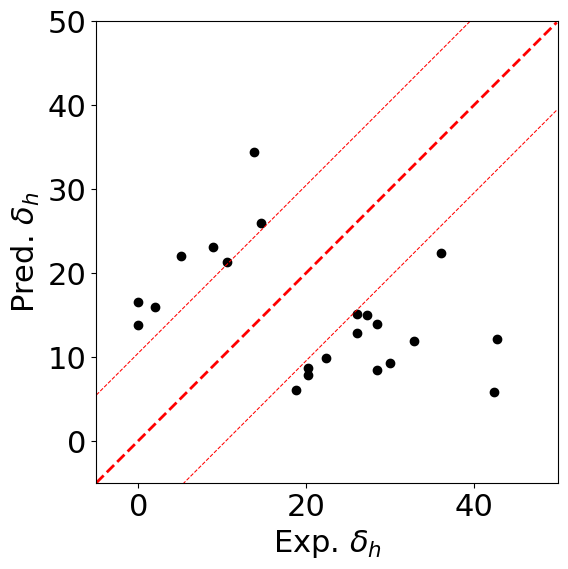

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Set font size
plt.rc('font', size=22)

n = 3  # residual threshold


# -------- Plot 1: all molecules --------
plt.figure(figsize=(6,6))

ln = np.arange(-5, 50, 0.2)

# ideal agreement and residual bounds
plt.plot(ln, ln, 'r--', linewidth=2)
plt.plot(ln, ln + n*sdr, 'r--', linewidth=0.75)
plt.plot(ln, ln - n*sdr, 'r--', linewidth=0.75)

# scatter plot
plt.scatter(x=fps_xgboost['actual'], 
            y=fps_xgboost['predict'], 
            color='green')

plt.xlabel(r'Exp. $\delta_h$')
plt.ylabel(r'Pred. $\delta_h$')

plt.xlim([-5,50])
plt.ylim([-5,50])

plt.gca().set_aspect('equal', adjustable='box')

# save figure
plt.savefig("xgboost_hansen_h_all_points.png", dpi=300, bbox_inches="tight")

plt.show()



# -------- Plot 2: outliers only --------
plt.figure(figsize=(6,6))

ln = np.arange(-5, 50, 0.2)

plt.plot(ln, ln, 'r--', linewidth=2)
plt.plot(ln, ln + n*sdr, 'r--', linewidth=0.75)
plt.plot(ln, ln - n*sdr, 'r--', linewidth=0.75)

plt.scatter(x=fps_xgboost_outliers['actual'], 
            y=fps_xgboost_outliers['predict'], 
            color='black')

plt.xlabel(r'Exp. $\delta_h$')
plt.ylabel(r'Pred. $\delta_h$')

plt.xlim([-5,50])
plt.ylim([-5,50])

plt.gca().set_aspect('equal', adjustable='box')

# save figure
plt.savefig("xgboost_hansen_h_outliers.png", dpi=300, bbox_inches="tight")

plt.show()

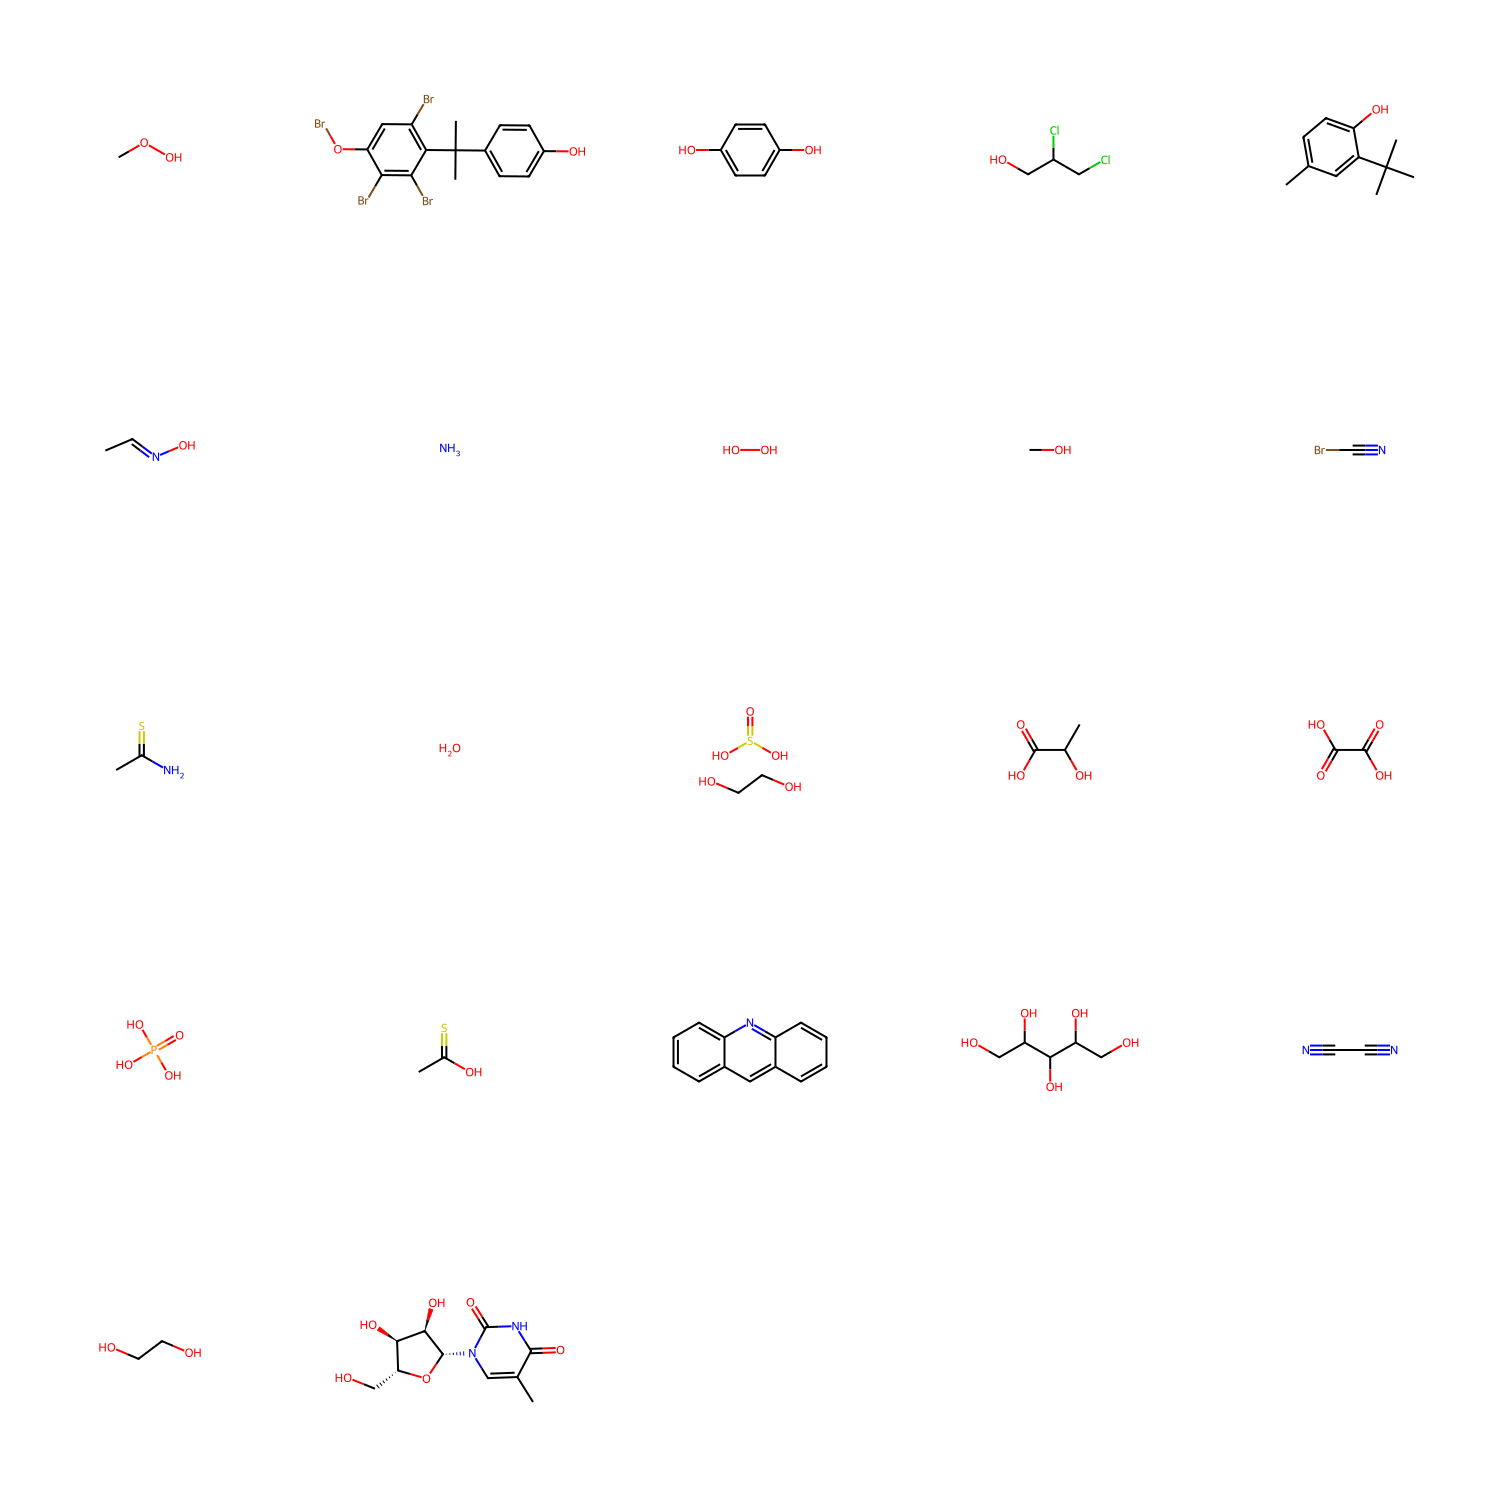

In [15]:
# draw n=3 outlier structure
outliners = [Chem.MolFromSmiles(x) for x in fps_xgboost_outliers['SMILES']]
Draw.MolsToGridImage(outliners, subImgSize=(300,300), molsPerRow=5, maxMols=50)

In [16]:
# n is 2 or 3. Points 2 or 3 sdr away from the prediction line are likely to be outliers
n = 2
fps_xgboost_outliers2 = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]
len(fps_xgboost_outliers2)

44

In [17]:
fps_xgboost_outliers2

,Mol_No,SMILES,actual,predict,residual,std_residual
121,722,CF,9.5,2.005487,-7.494513,-2.152020
122,724,C=O,15.4,6.972831,-8.427169,-2.419828
144,847,COO,30.0,9.295645,-20.704355,-5.945174
158,939,CN[C@@H](C)[C@H](O)c1ccccc1,24.1,14.599112,-9.500888,-2.728143
171,1012,Oc1c(cc(cc1[N+]([O-])=O)[N+]([O-])=O)[N+]([O-])=O,6.0,16.046667,10.046667,2.884861
178,1050,c1ccncc1,5.9,13.870397,7.970397,2.288668
180,1081,CC(C)(c1ccc(O)cc1)c2c(Br)cc(OBr)c(Br)c2Br,13.8,34.345990,20.545990,5.899700
15,72,Oc1ccc(O)cc1,27.2,14.977636,-12.222364,-3.509604
29,141,OCC(Cl)CCl,14.6,25.963308,11.363308,3.262929
39,239,Cc1ccc(O)c(c1)C(C)(C)C,10.5,21.306911,10.806911,3.103162


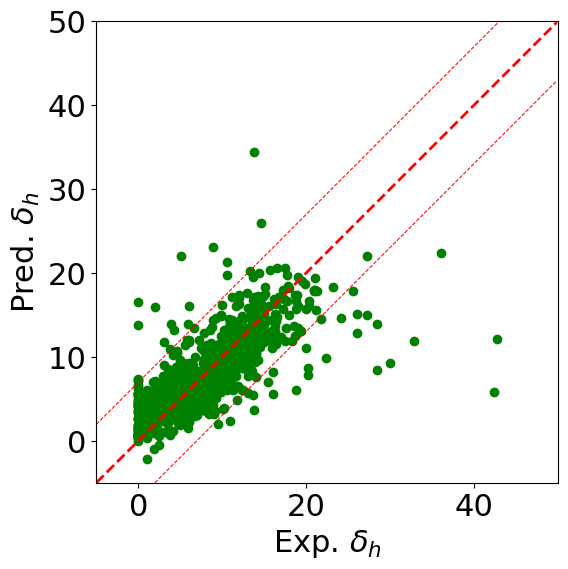

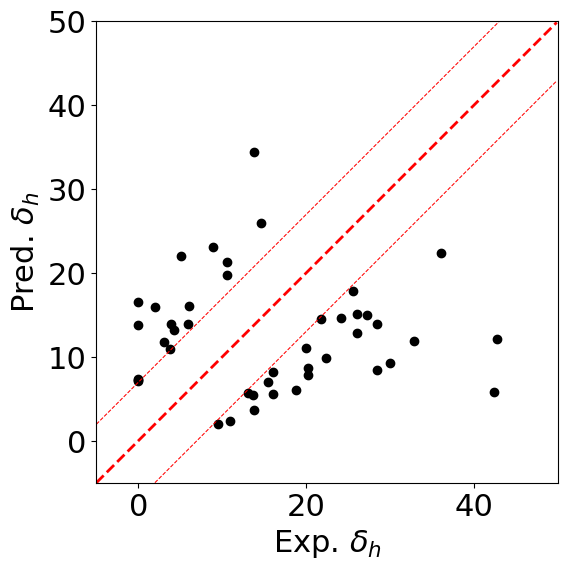

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Set font size
plt.rc('font', size=22)

# --- recalculate for Hansen h ---
fps_xgboost['residual'] = fps_xgboost['predict'] - fps_xgboost['actual']

sdr_h = np.sqrt((fps_xgboost['residual']**2).sum() / (len(fps_xgboost) - 2))

fps_xgboost['std_residual'] = fps_xgboost['residual'] / sdr_h

n = 2  # residual threshold
fps_xgboost_outliers = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]

# -------- Plot 1: all molecules --------
plt.figure(figsize=(6,6))

ln = np.arange(-5, 50, 0.2)

# ideal agreement and residual bounds
plt.plot(ln, ln, 'r--', linewidth=2)
plt.plot(ln, ln + n*sdr_h, 'r--', linewidth=0.75)
plt.plot(ln, ln - n*sdr_h, 'r--', linewidth=0.75)

# scatter plot
plt.scatter(
    x=fps_xgboost['actual'],
    y=fps_xgboost['predict'],
    color='green'
)

plt.xlabel(r'Exp. $\delta_h$')
plt.ylabel(r'Pred. $\delta_h$')

plt.xlim([-5, 50])
plt.ylim([-5, 50])

plt.gca().set_aspect('equal', adjustable='box')

# save figure
plt.savefig("xgboost_hansen_h2_all_points.png", dpi=300, bbox_inches="tight")
plt.show()


# -------- Plot 2: outliers only --------
plt.figure(figsize=(6,6))

plt.plot(ln, ln, 'r--', linewidth=2)
plt.plot(ln, ln + n*sdr_h, 'r--', linewidth=0.75)
plt.plot(ln, ln - n*sdr_h, 'r--', linewidth=0.75)

plt.scatter(
    x=fps_xgboost_outliers['actual'],
    y=fps_xgboost_outliers['predict'],
    color='black'
)

plt.xlabel(r'Exp. $\delta_h$')
plt.ylabel(r'Pred. $\delta_h$')

plt.xlim([-5, 50])
plt.ylim([-5, 50])

plt.gca().set_aspect('equal', adjustable='box')

# save figure
plt.savefig("xgboost_hansen_h2_outliers.png", dpi=300, bbox_inches="tight")
plt.show()

<>:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:13: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:25: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:26: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:13: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:25: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences wil

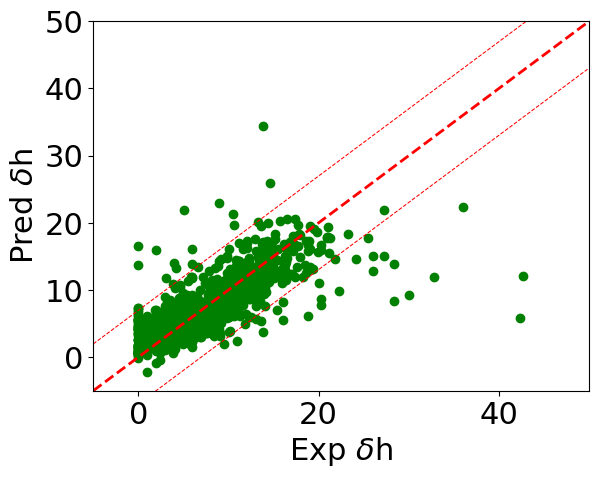

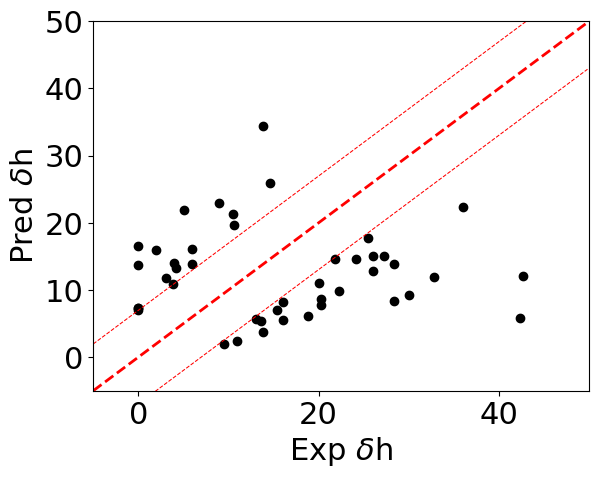

In [19]:
# plot two figures
plt.figure(2)

# plot of exp vs pred of all molecules in the dataset
# The thick red lines indicate ideal agreement between the predicted and experimental values. 
# The dashed red lines indicate 2 srd (n=2) away from the ideal agreement. 
ln = np.arange(-5, 50, 0.2)
plt.plot(ln, ln,'r--', linewidth = '2')
plt.plot(ln, ln+n*sdr,'r--', linewidth = '0.75')
plt.plot(ln, ln-n*sdr,'r--', linewidth = '0.75')
plt.scatter(x=fps_xgboost['actual'], y=fps_xgboost['predict'], color='green')
plt.xlabel('Exp $\delta$h')
plt.ylabel('Pred $\delta$h')
plt.xlim([-5,50])
plt.ylim([-5,50])
plt.show()

# Plot of the outliers identified 
# check visually to confirm they are on or beyond 2 srd
ln = np.arange(-5, 50, 0.2)
plt.plot(ln, ln,'r--', linewidth = '2')
plt.plot(ln, ln+n*sdr,'r--', linewidth = '0.75')
plt.plot(ln, ln-n*sdr,'r--', linewidth = '0.75')
plt.scatter(x=fps_xgboost_outliers2['actual'], y=fps_xgboost_outliers2['predict'], color='black')
plt.xlabel('Exp $\delta$h')
plt.ylabel('Pred $\delta$h')
plt.xlim([-5,50])
plt.ylim([-5,50])
plt.show()

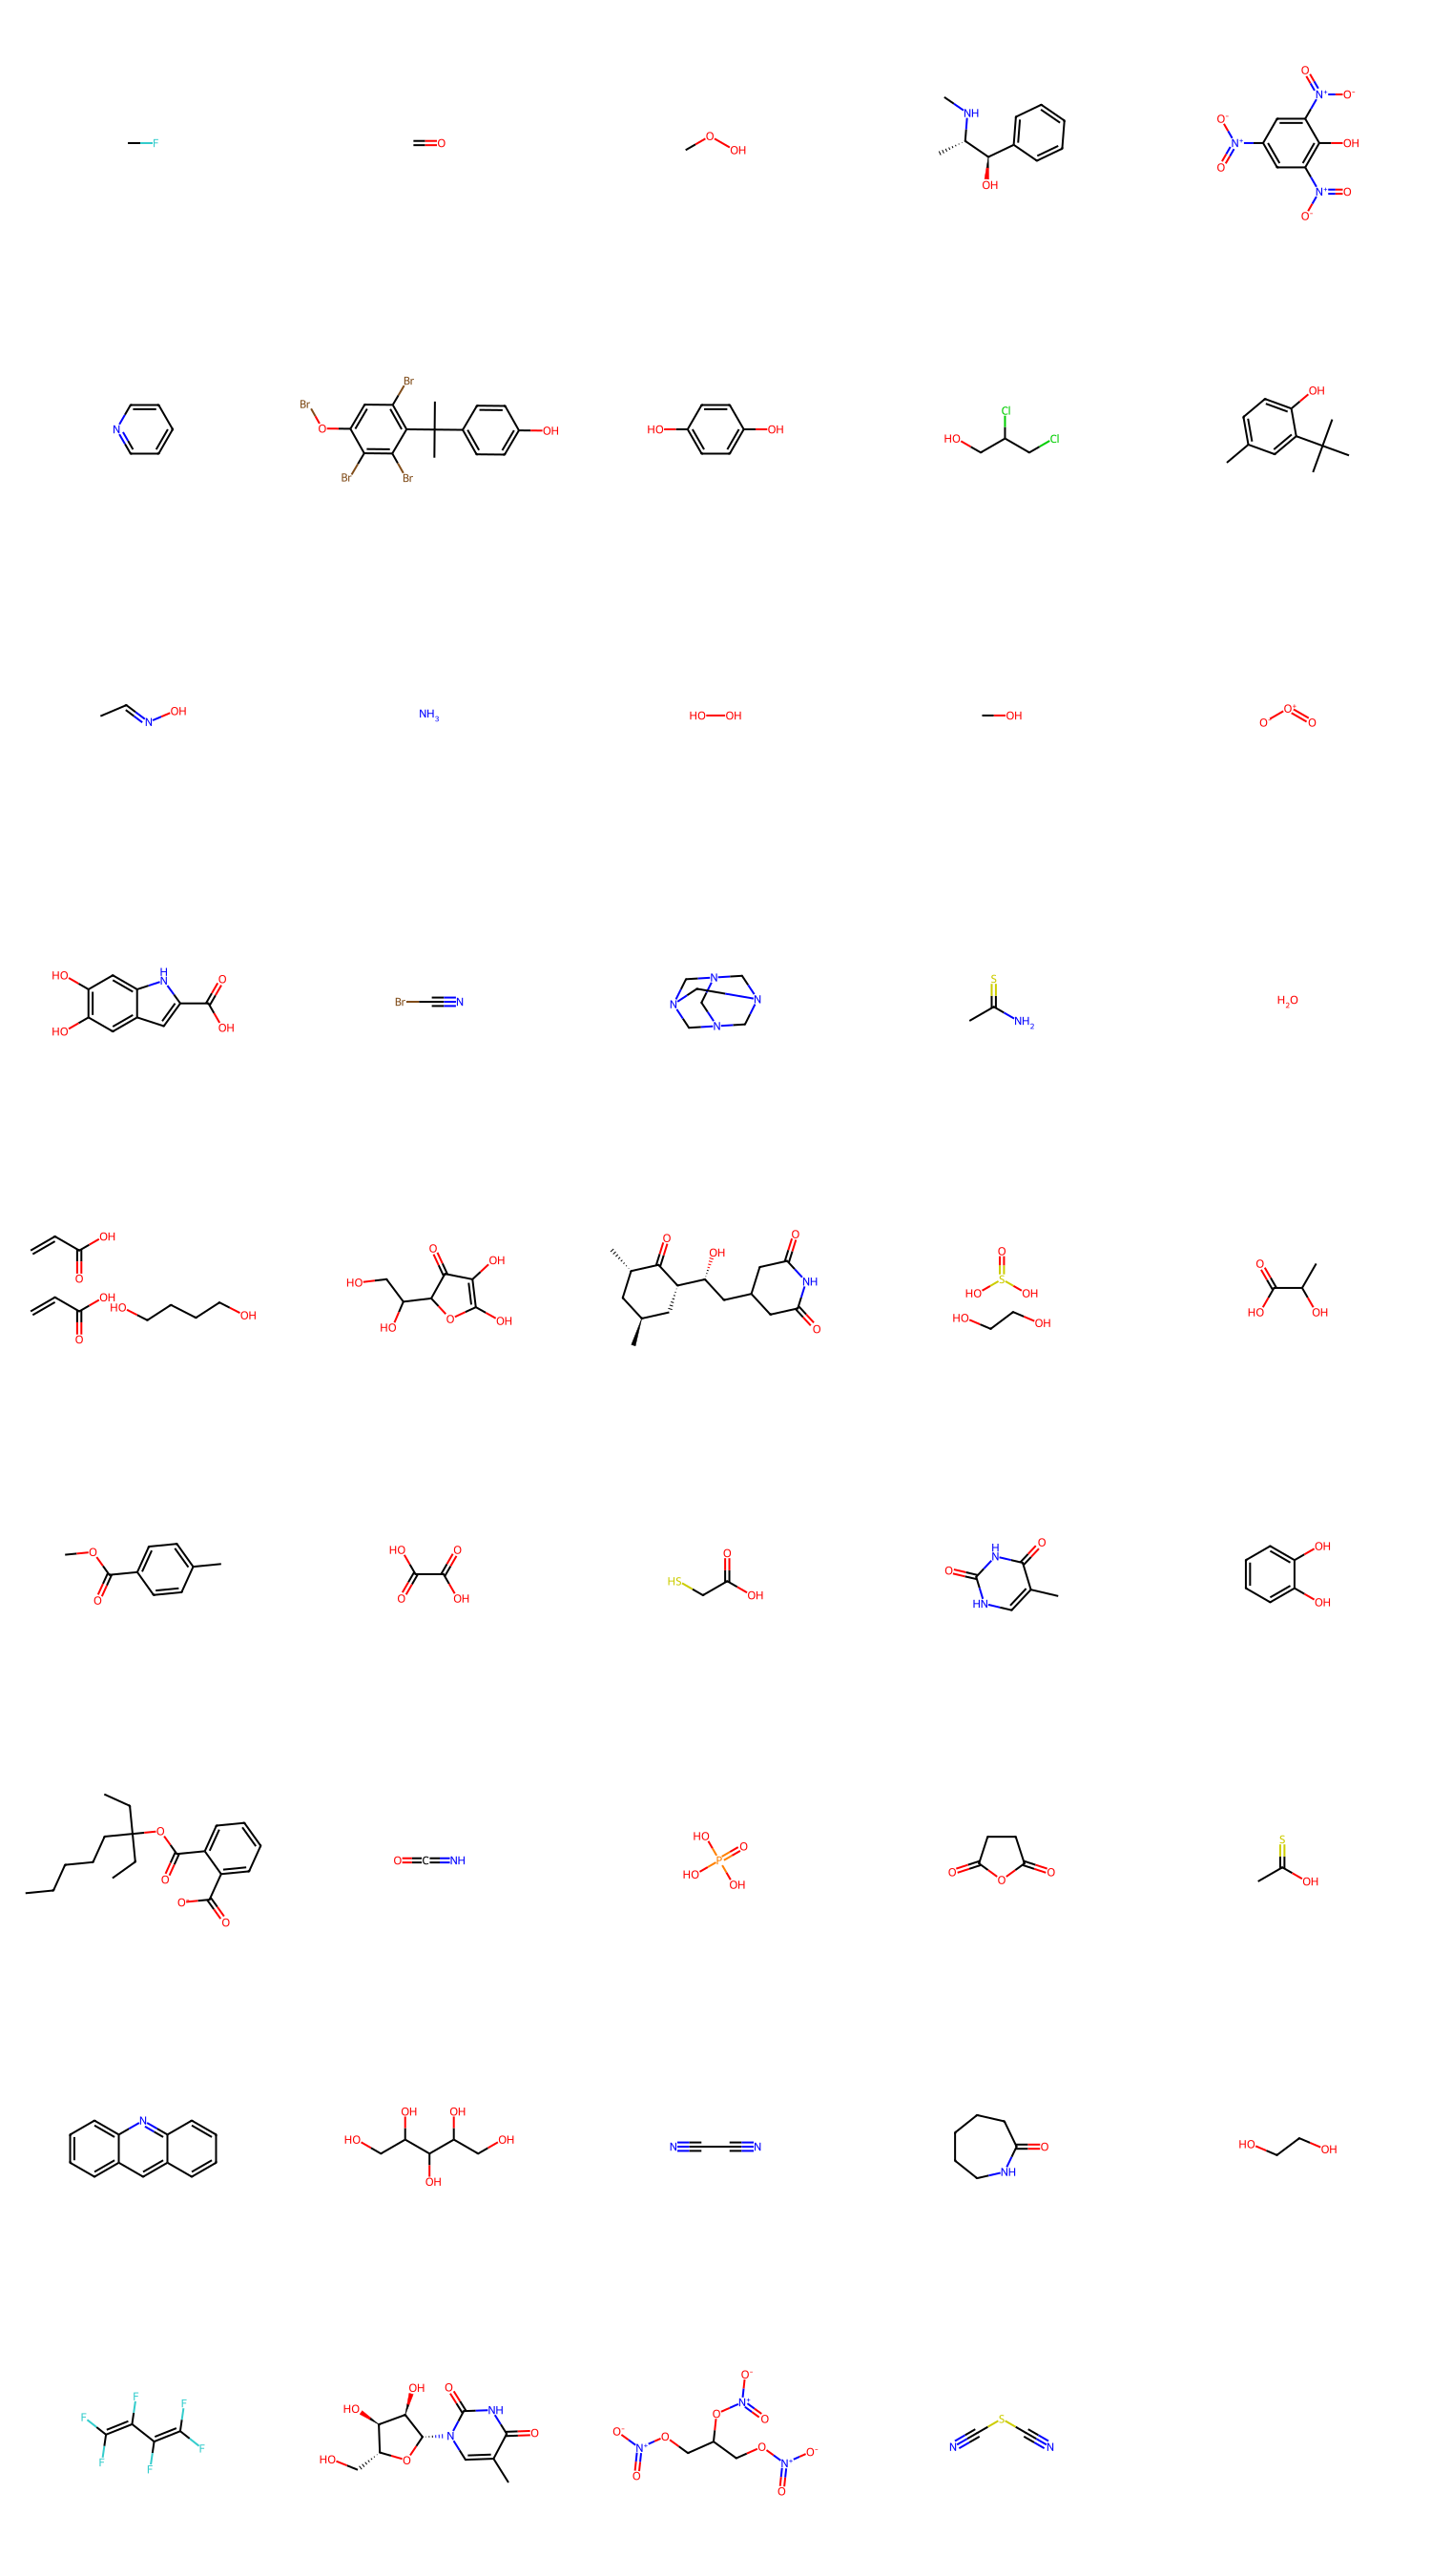

In [20]:
# draw n=2 outlier structure
outliners2 = [Chem.MolFromSmiles(x) for x in fps_xgboost_outliers2['SMILES']]
Draw.MolsToGridImage(outliners2, subImgSize=(300,300), molsPerRow=5, maxMols=100)

In [21]:
# save outliers (n=2) info to a csv file
fps_xgboost_outliers2.to_csv('fps_xgboost_h_outliers2.csv')

In [22]:
from rdkit.Chem import Descriptors
gpHSP_data = pd.read_csv('/Users/favour/Desktop/untitled folder/dataset/hansen_1k_smiles_shorter.csv')
mol_smiles = gpHSP_data['SMILES']

# calculate molecular weight of the full dataset
molwt = [(Descriptors.ExactMolWt(Chem.MolFromSmiles(x))) for x in gpHSP_data['SMILES']]
np_molwt = np.asarray(molwt)

# calculate molecular weight of outliers
molwt_outliers2 = [(Descriptors.ExactMolWt(Chem.MolFromSmiles(x))) for x in fps_xgboost_outliers2['SMILES']]
np_molwt_outliers2 = np.asarray(molwt_outliers2)

# Compare average molecular weight for full data and outliers
print(np.average(np_molwt))
print(np.average(np_molwt_outliers2))

131.2953603288794
128.4830099030434


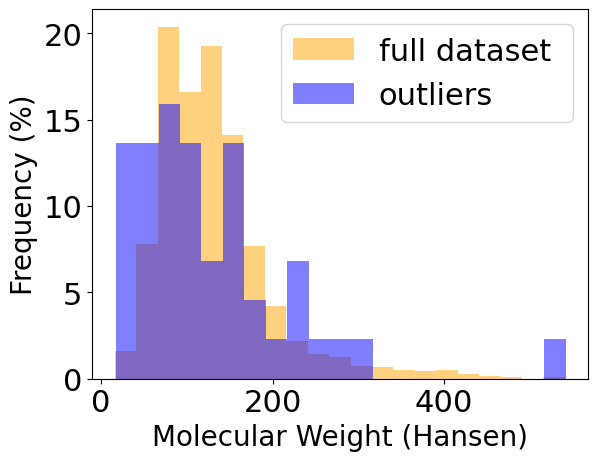

In [23]:
# plot molecular weight distribution for the full dataset and the outliers
bin_width = 25
df = pd.DataFrame(np_molwt, columns = ["full dataset "])
df2 = pd.DataFrame(np_molwt_outliers2, columns = ["outliers"])

ax = df.plot.hist(bins=(np.arange(min(molwt), max(molwt)+bin_width, bin_width)), alpha=0.5, color='orange', weights=np.ones_like(df.index) *100/ len(df))
df2.plot(kind='hist', bins=(np.arange(min(molwt_outliers2), max(molwt_outliers2)+bin_width, bin_width)), alpha=0.5, color='blue', weights=np.ones_like(df2.index) *100 /len(df2), ax=ax)
ax.set_xlabel("Molecular Weight (Hansen)", size=20)
ax.set_ylabel("Frequency (%)", size=20)
plt.show()

In [24]:
# n = 2 outliers
n = 2
fps_xgboost_outliers_n2 = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]
num_outliers_n2 = len(fps_xgboost_outliers_n2)

print("Number of outliers at n = 2:", num_outliers_n2)

# n = 3 outliers
n = 3
fps_xgboost_outliers_n3 = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]
num_outliers_n3 = len(fps_xgboost_outliers_n3)

print("Number of outliers at n = 3:", num_outliers_n3)

Number of outliers at n = 2: 44
Number of outliers at n = 3: 22
